# Creating an Observable from a Simulation
To run a refinement, MDMC makes quantitative comparisons between a dynamical property derived from an experiment, and the equivalent dynamical property calculated from our MD simulation. Within MDMC each of these properties is called an `Observable`. Examples of these observables are the [dynamic structure factor](https://en.wikipedia.org/wiki/Dynamic_structure_factor), $S(Q,\omega)$, and the [pair distribution function](https://en.wikipedia.org/wiki/Pair_distribution_function), $G(r)$.

Within a refinement, each `Observable` is calculated from MD automatically. However it is also useful to be able to calculate an `Observable` from an MD simulation and plot it, which is demonstrated in this tutorial.

This tutorial requires matplotlib, the Python plotting library, to be installed; if it is not installed, install it in the terminal with the command `pip3 install matplotlib`.

In [9]:
try:
    %matplotlib inline
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
except ImportError:
    print('Please install matplotlib and restart the kernel!')

### Running a simulation

Below we setup and run a simulation of liquid argon so that we have a `CompactTrajectory` from which to calculate an `Observable`.

If the building of the universe and simulation is confusing to you, please see the guides for how to [create atomic configurations](creating-atomic-configurations.ipynb), [define molecule interactions](defining-molecule-interactions.ipynb) and [run a simulation](running-a-simulation.ipynb) - or the [Argon a-to-z](../../../tutorials/Argon-a-to-z.ipynb) tutorial.

**As this is minimizing, equilibrating, and running a simulation, this should take ~3 minutes to execute**.

In [10]:
from MDMC.MD import *
from MDMC.MD.interactions import NonBondedForce
import numpy as np

# Build universe
universe = Universe(dimensions=38.4441)
Ar = Atom('Ar', charge=0.)
# Fill box with 1000 atoms, and hence atoms per AA^-3 density = 0.0176
universe.fill(Ar, num_struc_units=1000)
print('Universe contains {} Ar atoms'.format(len(universe.atoms)))
Ar_dispersion = NonBondedForce(universe,
                           Ar.atom_type,
                           cutoff=8.,
                           ewald=1e-6,
                           function=NonBonded(charge=0.0, epsilon=1.0243, sigma=3.36))

# MD Engine setup
simulation = Simulation(universe,
                        engine="openmm",
                        time_step=10.0,
                        temperature=120.,
                        traj_step=25)

simulation.minimize(n_steps=50)  # energy minimisation
simulation.run(n_steps=20000, equilibration=True)  # equilibration

simulation.run(12025)  # the actual run!
trajectory = simulation.trajectory

Universe created with:
Dimensions [38.44 38.44 38.44]
Universe contains 1000 Ar atoms
Simulation created with openmm engine and settings:
temperature: 120.0 K 




Before our excursion into calculating the dynamic structure factor from this trajectory, we define a helper function `plot_surface` which will let us easily visualise our observable as a 3D plot.

In [11]:
def plot_surface(x, y, z):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    X, Y = np.meshgrid(x, y)
    surf = ax.plot_surface(X, Y, z)
    plt.show()

### Calculating $S(Q,\omega)$

To see which observables can be calculated, use the `help` function to look at the observables module documentation:

In [12]:
from MDMC.trajectory_analysis import observables
help(observables)

Help on package MDMC.trajectory_analysis.observables in MDMC.trajectory_analysis:

NAME
    MDMC.trajectory_analysis.observables - Modules calculating observables from molecular dynamics trajectories.

DESCRIPTION
    Observables
    -----------
    FakeObservable / gauss2D
    DynamicStructureFactor / SQw
    CoherentDynamicStructureFactor / SQwCoherent / SQwCoh / SQw_coh
    IncoherentDynamicStructureFactor / SQwIncoherentSQwIncoh / SQw_incoh
    IntermediateScatteringFunction / FQt
    CoherentIntermediateScatteringFunction / FQtCoherent / FQtCoh / FQt_coh
    IncoherentIntermediateScatteringFunction / FQtIncoherentFQtIncoh / FQt_incoh
    MDANSEObservable / MDANSE
    PDF / PairDistributionFunction
    
    Examples
    --------
    Observables can be instantiated using the names above.
    
    For instance an SQw observable can be instantiated using either of the aliases:
    
    .. code-block:: python
    
        from MDMC.trajectory_analysis import observables
        sqw = o

Each observable may have one or more aliases - both `DynamicStructureFactor` or `SQw` can be used for calculating $S(Q,\omega)$.

Some of the details given below are specific to calculating the dynamic structure factor, however the general method can be followed for any observable.

Argon has comparable scattering lengths for both coherent and incoherent scattering, so the total scattering has clear contributions from each.  For this tutorial, we will simply calculate $S_{\mathrm{coh}}(Q,\omega)$ and compare it with experimental data; calculating the incoherent and total scattering can be done similarly with the objects `observables.SQwIncoh` or `observables.SQw`.

In [13]:
sqw_coh = observables.SQwCoh()

The dynamic structure factor has two independent variables; the scattering wavevector $Q$, and the energy transfer $\omega$ (or $E/\hbar$ where $\hbar$ denotes the reduced Planck constant).

The size of the simulation box defines the spacing (and therefore the lower bound) of $Q$ values; however any Q values can be specified for calculating $S(Q,\omega)$ and MDMC will simply calculate it for valid values.

Here, we use the `np.arange` function to create an array of Q-values, evenly spaced in steps of 0.3 between 0.42 and 3.8.

In [14]:
Q = np.arange(start=0.42, stop=3.8, step=0.3)
print('Q will be calculated for values of: {}'.format(Q))

Q will be calculated for values of: [0.42 0.72 1.02 1.32 1.62 1.92 2.22 2.52 2.82 3.12 3.42 3.72]


The total duration of the trajectory defines the smallest spacing of the $E$ values.  If $E$ values are not specified, MDMC will simply calculate the $E$ values with this spacing.  However for this setting there will only be two points in the trajectory contributing to each energy bin and the statistics will be poor.

**should take ~30s to execute**:

In [15]:
# Set the Q values for the Q independent variable
sqw_coh.independent_variables = {'Q':Q}

# Calculate the coherent dynamic structure factor
sqw_coh.calculate_from_MD(trajectory)

and indeed, the plot betrays our poor statistics:

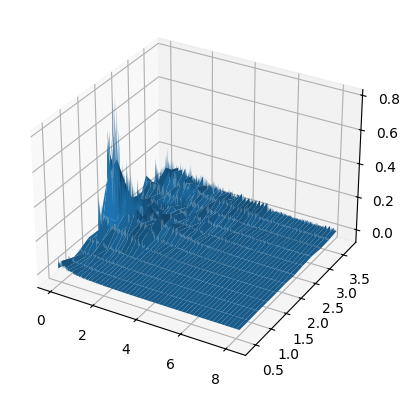

In [16]:
plot_surface(sqw_coh.E, sqw_coh.Q, sqw_coh.SQw[0])

Therefore it is strongly recommended that you specify the $E$ values for calculating the dynamic structure factor.

The allowed values of $E$ (in meV) are determined by trajectory times.  To aid in calculating these, the `calculate_E` method
can be used, which requires the time step of the trajectory (in fs) and the total number of E values to be calculated.  The number of E values should be changed to improve the statistics, but somewhere in the range of 1/4 to 1/8 of the total number of trajectory configurations (i.e. the number of times for which a configuration was recorded) will often be reasonable:

In [17]:
# This subtracts the time of the zeroeth step from the time of the first step
# It should be equal to the time_step * traj_step passed to Simulation
trajectory_timestep = trajectory.times[1] - trajectory.times[0]
print('CompactTrajectory time step: {} fs'.format(trajectory_timestep))

n_configurations = len(trajectory.times)
print('Number of trajectory configurations: {}'.format(n_configurations))

CompactTrajectory time step: 250.00000000000006 fs
Number of trajectory configurations: 481


In [18]:
E = sqw_coh.calculate_E((n_configurations - 1) / 6, trajectory_timestep)
print('Calculated E values are: \n{} meV'.format(E))

Calculated E values are: 
[0.         0.10339169 0.20678338 0.31017508 0.41356677 0.51695846
 0.62035015 0.72374185 0.82713354 0.93052523 1.03391692 1.13730862
 1.24070031 1.344092   1.44748369 1.55087539 1.65426708 1.75765877
 1.86105046 1.96444216 2.06783385 2.17122554 2.27461723 2.37800893
 2.48140062 2.58479231 2.688184   2.79157569 2.89496739 2.99835908
 3.10175077 3.20514246 3.30853416 3.41192585 3.51531754 3.61870923
 3.72210093 3.82549262 3.92888431 4.032276   4.1356677  4.23905939
 4.34245108 4.44584277 4.54923447 4.65262616 4.75601785 4.85940954
 4.96280124 5.06619293 5.16958462 5.27297631 5.376368   5.4797597
 5.58315139 5.68654308 5.78993477 5.89332647 5.99671816 6.10010985
 6.20350154 6.30689324 6.41028493 6.51367662 6.61706831 6.72046001
 6.8238517  6.92724339 7.03063508 7.13402678 7.23741847 7.34081016
 7.44420185 7.54759355 7.65098524 7.75437693 7.85776862 7.96116031
 8.06455201 8.1679437 ] meV


Of course if the $E$ resolution required is lower (i.e. step between the `E` values can be larger), the number of E values specified can be reduced:

In [19]:
print('A reduced E resolution: \n{} meV'.format(sqw_coh.calculate_E((n_configurations - 1) / 24, trajectory_timestep)))

A reduced E resolution: 
[0.         0.41356677 0.82713354 1.24070031 1.65426708 2.06783385
 2.48140062 2.89496739 3.30853416 3.72210093 4.1356677  4.54923447
 4.96280124 5.376368   5.78993477 6.20350154 6.61706831 7.03063508
 7.44420185 7.85776862] meV


Now we can use `Q` and `E` to set the indepedendent variables of `sqw_coh`:

In [20]:
sqw_coh.independent_variables = {'E':E,
                                 'Q':Q}

Using this binning, we recalculate the dynamic structure factor, which is smoother due to better statistics.

 **This calculation should take ~30s.**:

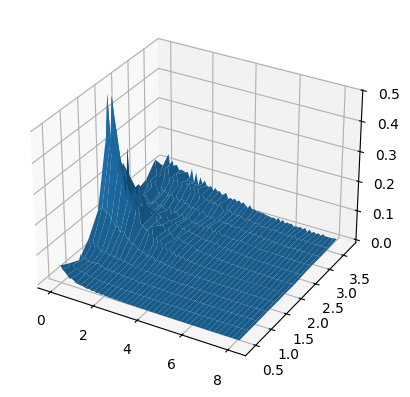

In [21]:
sqw_coh.calculate_from_MD(trajectory)
plot_surface(sqw_coh.E, sqw_coh.Q, sqw_coh.SQw[0])

We can compare this with experimental data measured using quasi-elastic neutron scattering (QENS) data (specifically here the [van Well et al. (1985)](https://doi.org/10.1103/PhysRevA.31.3391) data, seen in detail in the [Argon a-to-z](../../../tutorials/Argon-a-to-z.ipynb) tutorial) by reading the data into an SQwCoh object:

In [22]:
sqw_exp = observables.SQwCoh().read_from_file(reader='xml_SQw', file_name='./data/Well_s_q_omega_Ar_data.xml')

The independent and dependent variables are read into the same attributes (`sqw_exp.E`, `sqw_exp.Q`, and `sqw_exp.SQw`) as if they had been calculated from MD (as in `sqw_coh` above).

For many QENS datasets (if not most) the instrument resolution has not been removed, and to compare with MD simulation this requires the simulation output to be smoothed to the instrument resolution. One way this can be done is using the optional `energy_resolution`:

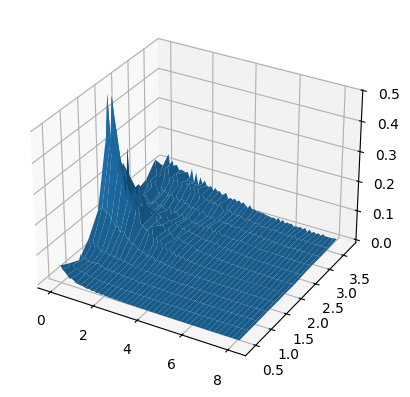

In [23]:
# energy_resolution is the FWHM of the instrumentation's resolution function expressed in ueV (micro eV).
# It is used to smooth the calculated S(Q,w) with a Gaussian window in order to match the values obtained experimentally.
sqw_coh.calculate_from_MD(trajectory, energy_resolution={'gaussian': 1.0e3})

plot_surface(sqw_coh.E, sqw_coh.Q, sqw_coh.SQw[0])

## Other observables

The same applies for the observables, such as the pair distribution function $G(r)$.  To determine how to calculate another observables from an MD trajectory, please see the associated help documentation:

In [24]:
help(observables.PDF.calculate_from_MD)

Help on function calculate_from_MD in module MDMC.trajectory_analysis.observables.pdf:

calculate_from_MD(self, MD_input: MDMC.trajectory_analysis.compact_trajectory.CompactTrajectory, verbose: int = 0, **settings: Any)
    Calculate the pair distribution function, :math:`G(r)` from a ``CompactTrajectory``.
    
    The partial pair distribution (from __) for a pair i-j, :math:`g_{ij}`, is:
    
    .. math::
    
        g_{ij}(r) = \frac{h_{ij}(r)}{4 \pi r^2 \rho_{j} \Delta{r}}
    
    where :math:`h_{ij}`` is the histogram of distances of :math:`j` element
    atoms around atoms of element :math:`i`, with bins of size
    :math:`\Delta{r}`, and :math:`\rho_{j}` is the number density of
    atoms of element :math:`j`. As :math:`g_{ij}(0) = 0`, it is evident that
    :math:`G(0) = -\sum\limits_{i,j}^{N_{elements}} c_ic_jb_ib_j`.
    
    The total pair distribution function (``pdf.PDF``) has the form:
    
    .. math::
    
        G(r) = \sum_{i,j}^{N_{elements}} c_ic_jb_ib_j(g_{ij